# CDC

https://wonder.cdc.gov/

There are 6 tables in database
- **mcd99_cod:** provides data on a cod basis (1999 - 2020 data)
- **mcd18_cod:** provides data on a cod basis (2018+)
- **mcd18_monthly:** provides monthly data (2018+)
- **mi:** provides data from on a more aggregate level (1979-2020)
- **mcd99_check:** provides a check to the cod table as it isn't using grouping (1999 - 2020 data)
- **mcd18_check:** provides a check to the cod table as it isn't using groupings (2018+ data)

sources:
- 1979-1998: https://wonder.cdc.gov/controller/datarequest/D16
- 1999-2020: https://wonder.cdc.gov/controller/datarequest/D76
- 2018+: https://wonder.cdc.gov/controller/datarequest/D176

code support:
- https://github.com/alipphardt/cdc-wonder-api


## Import

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
from sklearn.linear_model import LinearRegression

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai.experience import charters
from morai.integrations import cdc
from morai.models import core
from morai.utils import helpers, sql

In [3]:
pd.options.display.float_format = "{:,.2f}".format

In [4]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

In [5]:
db_filepath = r"files/integrations/cdc/cdc.sql"

In [6]:
tables = sql.get_tables(db_filepath=db_filepath)
tables

['mcd99_cod',
 'mcd79_mi',
 'mcd99_mi',
 'mcd79_check',
 'mcd99_check',
 'mcd18_check',
 'mcd18_cod',
 'mcd18_monthly',
 'mcd18_mi']

## COD

### SQL
Load from SQL database

In [18]:
mcd99_cod = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_cod")

In [10]:
mcd18_cod = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_cod")

### Aggregate
Aggregating the historical and provisional and mapping columns to more friendly names

In [16]:
# variable to map
category_col = "simple_grouping"

In [19]:
# filter and concat
mcd18_cod = mcd18_cod[mcd18_cod["year"] >= 2021]
cod_all = pd.concat([mcd99_cod, mcd18_cod], ignore_index=True)

In [79]:
# map the variable from reference
cod_all = cdc.map_reference(
    df=cod_all, col=category_col, on_dict={"icd_sub_chapter": "wonder_sub_chapter"}
)

In [80]:
# normalize partial deaths in recent year
cod_all["deaths"] = cod_all["deaths"].astype(float)
data_through = pd.Timestamp(mcd18_cod["data_through"].max())
start_of_year = pd.Timestamp(f"{data_through.year}-01-01")
days_elapsed = (data_through - start_of_year).days + 1
factor = 365 / days_elapsed
mask = cod_all["year"] == data_through.year
cod_all.loc[mask, "deaths"] = cod_all.loc[mask, "deaths"] * factor

In [81]:
# create totals column
totals = cod_all.groupby("year").sum(numeric_only=True).reset_index()
totals[category_col] = "total"
totals["age_groups"] = "total"
cod_all = pd.concat([cod_all, totals], ignore_index=True)

In [82]:
category_orders = charters.get_category_orders(
    df=cod_all, category=category_col, measure="deaths"
)

### Predict

In [83]:
# train the data based on year and the category using linear regression
train_df = cod_all[(cod_all["year"] >= 2015) & (cod_all["year"] <= 2019)]
train_df = train_df.groupby(["year", category_col])["deaths"].sum().reset_index()

In [84]:
# create the models
models = {}
for cod in train_df[category_col].unique():
    cod_subset = train_df[train_df[category_col] == cod]
    X = (cod_subset["year"] - 2015).values.reshape(-1, 1)
    y = cod_subset["deaths"].values
    model = LinearRegression().fit(X, y)
    models[cod] = {
        "model": model,
        "coef": model.coef_[0],
        "intercept": model.intercept_,
    }

In [85]:
# make the predictions
test_df = cod_all[(cod_all["year"] >= 2020)]
test_df = test_df.groupby(["year", category_col])["deaths"].sum().reset_index()

for cod, model in models.items():
    mask = test_df[category_col] == cod
    if mask.sum() > 0:
        X = (test_df.loc[mask, "year"] - 2015).values.reshape(-1, 1)
        test_df.loc[mask, "pred"] = model["model"].predict(X)

test_df["diff_abs"] = test_df["deaths"] - test_df["pred"]
test_df["diff_pct"] = (test_df["deaths"] - test_df["pred"]) / test_df["pred"]

### Chart

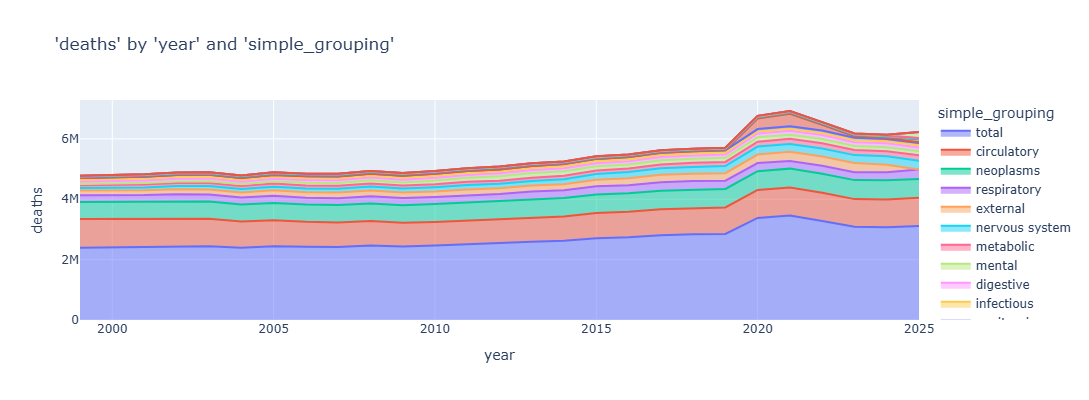

In [86]:
charters.chart(
    df=cod_all,
    x_axis="year",
    y_axis="deaths",
    color=category_col,
    type="area",
    category_orders=category_orders,
)

In [87]:
cod_all["crude_rate"] = cod_all["deaths"] / cod_all["population"] * 1000

In [88]:
cod_all[(cod_all["simple_grouping"] == "neoplasms") & (cod_all["year"] == 2023)]

,year,icd_sub_chapter,age_groups,deaths,population,crude_rate,added_at,data_through,simple_grouping
24518,2023,Malignant neoplasms,< 1 year,47.00,"3,648,654.00",0.01,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24519,2023,Malignant neoplasms,1-4 years,269.00,"14,862,506.00",0.02,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24520,2023,Malignant neoplasms,5-14 years,850.00,"40,987,321.00",0.02,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24521,2023,Malignant neoplasms,15-24 years,"1,463.00","43,886,652.00",0.03,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24522,2023,Malignant neoplasms,25-34 years,"3,503.00","45,542,516.00",0.08,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24523,2023,Malignant neoplasms,35-44 years,"11,291.00","44,390,693.00",0.25,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24524,2023,Malignant neoplasms,45-54 years,"32,867.00","40,493,781.00",0.81,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24525,2023,Malignant neoplasms,55-64 years,"101,714.00","41,854,411.00",2.43,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24526,2023,Malignant neoplasms,65-74 years,"180,690.00","34,685,284.00",5.21,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms
24527,2023,Malignant neoplasms,75-84 years,"177,816.00","18,368,097.00",9.68,2025-06-08 20:13:03,2025-05-24 00:00:00,neoplasms


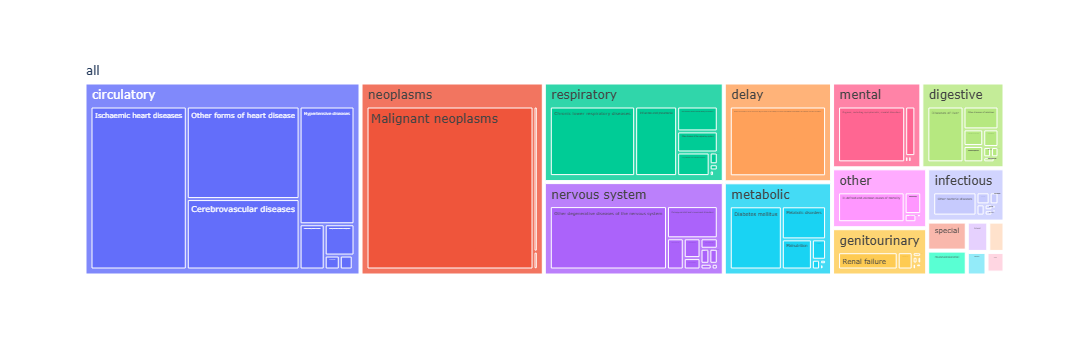

In [92]:
fig = px.treemap(
    cod_all[(cod_all["simple_grouping"] != "total") & (cod_all["year"] == 2025)],
    path=[px.Constant("all"), "simple_grouping", "icd_sub_chapter"],
    values="deaths",
)
fig

In [90]:
summary = charters.chart(
    df=test_df,
    x_axis="year",
    y_axis="diff_pct",
    color=category_col,
    type="area",
    category_orders=category_orders,
    display=False,
)
pivot = summary.pivot(index=category_col, columns="year", values="diff_pct")
pivot.index = pd.Categorical(
    pivot.index, categories=category_orders[category_col], ordered=True
)
pivot = pivot.sort_index().reset_index()
pivot

year,index,2020,2021,2022,2023,2024,2025
0,total,0.16,0.18,0.10,0.02,0.00,0.01
1,circulatory,0.05,0.04,0.04,-0.00,-0.01,-0.00
2,neoplasms,0.00,0.01,0.01,0.02,0.03,0.00
3,respiratory,-0.03,-0.11,-0.07,-0.08,-0.07,0.10
4,external,0.08,0.15,0.12,0.06,-0.14,NaN
5,nervous system,0.07,-0.02,-0.01,-0.06,-0.04,-0.02
6,metabolic,0.13,0.14,0.12,0.05,0.03,0.03
7,mental,0.11,0.02,0.04,-0.00,-0.01,0.01
8,digestive,0.08,0.15,0.12,0.07,0.05,0.01
9,infectious,0.07,0.10,0.16,0.18,0.19,0.31


In [91]:
summary = charters.chart(
    df=test_df,
    x_axis="year",
    y_axis="diff_abs",
    color=category_col,
    type="area",
    category_orders=category_orders,
    display=False,
)
pivot = summary.pivot(index=category_col, columns="year", values="diff_abs")
pivot.index = pd.Categorical(
    pivot.index, categories=category_orders[category_col], ordered=True
)
pivot = pivot.sort_index()
pivot

year,2020,2021,2022,2023,2024,2025
total,"476,940.50","519,476.20","297,208.90","70,501.60","13,604.30","19,897.83"
circulatory,"41,554.30","33,989.00","33,615.70","-2,484.60","-6,973.90","-4,680.07"
neoplasms,"2,239.80","4,401.00","6,663.20","11,037.40","16,899.60",664.27
respiratory,"-8,267.80","-29,549.60","-18,628.40","-22,494.20","-20,562.00","27,680.42"
external,"20,718.80","41,218.40","32,672.00","17,077.60","-42,454.80",NaN
nervous system,"16,078.20","-5,632.00","-3,622.20","-15,371.40","-12,373.60","-5,869.84"
metabolic,"19,435.60","21,684.00","18,455.40","7,880.80","5,096.20","4,886.95"
mental,"14,322.40","2,483.20","5,328.00",-272.20,"-1,746.40","1,744.81"
digestive,"9,633.40","17,525.60","14,372.80","8,050.00","6,017.20",806.98
infectious,"4,558.80","6,468.80","9,531.80","10,527.80","10,849.80","17,140.64"


In [23]:
deaths_pivot, names_pivot = cdc.get_top_deaths_by_age_group(df=cod_all, year=2018)

## Monthly

### SQL

In [14]:
mcd18_monthly = cdc.get_cdc_data_sql(
    db_filepath=db_filepath, table_name="mcd18_monthly"
)

### Chart

In [25]:
charters.chart(
    df=mcd18_monthly,
    x_axis="month",
    y_axis="deaths",
    type="area",
)

## MI

### SQL

In [7]:
mcd79_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd79_mi")
mcd99_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_mi")
mcd18_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_mi")
mcd18_mi = mcd18_mi[mcd18_mi["year"] >= 2021]
mi = pd.concat([mcd79_mi, mcd99_mi, mcd18_mi], axis=0, ignore_index=True)

In [8]:
mi = cdc.map_reference(
    df=mi,
    col="value",
    on_dict={"age_groups": "key"},
    sheet_name="mapping",
    category="bin_age",
)
mi = mi.drop("age_groups", axis=1)
mi = mi.rename(columns={"value": "age_groups"})

### Calculate

In [9]:
# filters
mi = mi[mi["year"] < 2020]

In [10]:
mi_df = cdc.calc_mi(df=mi, rolling=10)

 2025-10-16 23:07:54 | morai.integrations.cdc | INFO     | calculating mortality improvement by using a `2000 age adjusted` crude mortality rate 


In [25]:
mi[(mi['age_groups']=='45-54 years')&(mi['year']>=2009)].groupby(["year", "age_groups"])[["deaths", "population"]].sum().reset_index()[["year", "age_groups", "deaths", "population"]]

,year,age_groups,deaths,population
0,2009,45-54 years,187568,"44,867,088.00"
1,2010,45-54 years,183207,"45,006,716.00"
2,2011,45-54 years,183247,"44,718,203.00"
3,2012,45-54 years,179463,"44,268,738.00"
4,2013,45-54 years,177724,"43,767,532.00"
5,2014,45-54 years,175917,"43,458,851.00"
6,2015,45-54 years,174494,"43,188,161.00"
7,2016,45-54 years,173516,"42,786,679.00"
8,2017,45-54 years,170142,"42,374,952.00"
9,2018,45-54 years,164837,"41,631,699.00"


### Chart

In [30]:
charters.compare_rates(
    df=mi_df,
    x_axis="year",
    rates=["1_year_mi", "10_year_mi", "whl_3"],
)

In [31]:
mi_df.tail(10)

,year,crude_adj,deaths,1_year_mi,10_year_mi,whl_3
31,2010,754.31,2468435,0.00,0.01,0.01
32,2011,748.71,2515458,0.01,0.01,0.01
33,2012,740.09,2543279,0.01,0.02,0.01
34,2013,739.19,2596993,0.00,0.01,0.01
35,2014,731.81,2626418,0.01,0.01,0.00
36,2015,740.13,2712630,-0.01,0.01,0.00
37,2016,735.62,2744248,0.01,0.01,0.00
38,2017,738.57,2813503,-0.00,0.01,0.00
39,2018,730.08,2839205,0.01,0.01,0.01
40,2019,721.50,2854838,0.01,0.00,0.01


## Excess

### SQL

In [171]:
mcd99_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_mi")
mcd18_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_mi")
mcd18_mi = mcd18_mi[mcd18_mi["year"] >= 2021]
excess = pd.concat([mcd99_mi, mcd18_mi], axis=0, ignore_index=True)

In [172]:
excess = cdc.map_reference(
    df=excess,
    col="value",
    on_dict={"age_groups": "key"},
    sheet_name="mapping",
    category="bin_age_int",
)
excess = excess.rename(columns={"value": "mapped_age"})

In [173]:
# normalize partial deaths in recent year
excess["deaths"] = excess["deaths"].astype(float)
data_through = pd.Timestamp(mcd18_mi["data_through"].max())
start_of_year = pd.Timestamp(f"{data_through.year}-01-01")
days_elapsed = (data_through - start_of_year).days + 1
factor = 365 / days_elapsed
mask = excess["year"] == data_through.year
excess.loc[mask, "deaths"] = excess.loc[mask, "deaths"] * factor

In [174]:
excess_grouped = (
    excess.groupby(["year", "mapped_age"], observed=True)
    .sum(numeric_only=True)
    .reset_index()
)
excess_grouped = excess_grouped[(excess_grouped["year"] >= 2015)]

In [175]:
# adjust population
# train the data based on year and the category using linear regression
max_year = excess_grouped["year"].max()
base_year = max_year - 2
train_df = excess_grouped[
    (excess_grouped["year"] >= 2015) & (excess_grouped["year"] <= 2019)
]
train_df = train_df.groupby(["year", "mapped_age"])["population"].sum().reset_index()

# create the age models
models = {}
for age in train_df["mapped_age"].unique():
    age_subset = train_df[train_df["mapped_age"] == age]
    X = (age_subset["year"] - 2015).values.reshape(-1, 1)
    y = age_subset["population"].values
    model = LinearRegression().fit(X, y)
    models[age] = {
        "model": model,
        "coef": model.coef_[0],
        "intercept": model.intercept_,
    }
bases = (
    excess_grouped[excess_grouped["year"] == 2023]
    .set_index("mapped_age")["population"]
    .to_dict()
)
coefs = {age: m["coef"]/m["intercept"] for age, m in models.items()}

# prediction
for year in [base_year + 1, base_year + 2]:
    mask = excess_grouped["year"] == year
    for age in excess_grouped.loc[mask, "mapped_age"].unique():
        coef = coefs.get(age, 0)
        base = bases.get(age, 0)
        idx = (excess_grouped["year"] == year) & (excess_grouped["mapped_age"] == age)
        excess_grouped.loc[idx, "population"] = (1+coef) ** (year - base_year) * base

In [176]:
excess_grouped["qx_raw"] = excess_grouped["deaths"] / excess_grouped["population"]
forecast_years = max_year - 2019

### Calculate

In [177]:
train_df = excess_grouped[
    (excess_grouped["year"] >= 2015) & (excess_grouped["year"] <= 2019)
].copy()
model = core.LeeCarter(
    age_col="mapped_age",
    year_col="year",
    actual_col="deaths",
    expose_col="population",
    interval=1,
)
fit_df = model.structure_df(train_df)
fit_df = model.fit(fit_df)

 2025-07-13 23:55:24 | morai.models.core | INFO     | initialized LeeCarter 
 2025-07-13 23:55:24 | morai.models.core | INFO     | grouping data by age and year 
 2025-07-13 23:55:24 | morai.models.core | INFO     | calculating qx_raw rates using deaths and population 
 2025-07-13 23:55:24 | morai.models.core | INFO     | floored 0 rates to 0.000001 and capped 0 rates to 0.999999. 
 2025-07-13 23:55:24 | morai.models.core | INFO     | crude_df shape: (55, 5) 
 2025-07-13 23:55:24 | morai.models.core | INFO     | creating Lee Carter model with qx_raw rates... 
 2025-07-13 23:55:24 | morai.models.core | INFO     | age range: 0, 85 
 2025-07-13 23:55:24 | morai.models.core | INFO     | year range: 2015, 2019 
 2025-07-13 23:55:24 | morai.models.core | INFO     | creating `11` intervals 
 2025-07-13 23:55:24 | morai.models.core | INFO     | adding qx_lc to lc_df 


In [178]:
forecast_df = model.forecast(years=forecast_years)
forecast_df = pd.concat(
    [fit_df[["year", "mapped_age", "qx_lc"]], forecast_df], axis=0
).reset_index()

 2025-07-13 23:55:25 | morai.models.core | INFO     | forecasting qx_lc using deterministic random walk... 


In [179]:
excess_grouped = pd.merge(
    excess_grouped,
    forecast_df[["mapped_age", "year", "qx_lc"]],
    on=["mapped_age", "year"],
    how="left",
)
excess_grouped["deaths_lc"] = excess_grouped["population"] * excess_grouped["qx_lc"]

### Chart

In [180]:
charters.compare_rates(
    excess_grouped,
    x_axis="year",
    rates=["qx_raw", "qx_lc"],
    weights=["population"],
)

 2025-07-13 23:55:26 | morai.experience.charters | INFO     | The weights list is 1 long and should be 2 long. Using the first weight for all weights. 


In [181]:
result = (
    excess_grouped.groupby(["year"], observed=True).sum(numeric_only=True).reset_index()
)
result["excess_lc"] = result["deaths"] / result["deaths_lc"]
result["qx_raw"] = result["deaths"] / result["population"]
result["qx_lc"] = result["deaths_lc"] / result["population"]
pd.options.display.float_format = "{:.4f}".format
result

,year,deaths,population,qx_raw,qx_lc,deaths_lc,excess_lc
0,2015,2712630.0000,321418820.0000,0.0084,0.0084,2712630.0000,1.0000
1,2016,2744248.0000,323127513.0000,0.0085,0.0085,2744248.0000,1.0000
2,2017,2813503.0000,325719178.0000,0.0086,0.0086,2813503.0000,1.0000
3,2018,2839205.0000,327167434.0000,0.0087,0.0087,2839205.0000,1.0000
4,2019,2854838.0000,328239523.0000,0.0087,0.0087,2854838.0000,1.0000
5,2020,3383729.0000,329484123.0000,0.0103,0.0088,2885693.6387,1.1726
6,2021,3464231.0000,331893745.0000,0.0104,0.0084,2798074.8858,1.2381
7,2022,3279857.0000,333287557.0000,0.0098,0.0087,2902569.2697,1.1300
8,2023,3090964.0000,334914895.0000,0.0092,0.0087,2900873.3404,1.0655
9,2024,3072578.0000,337199501.4925,0.0091,0.0087,2949114.5925,1.0419


In [163]:
charters.chart(
    excess_grouped,
    x_axis="year",
    y_axis="population",
    color="mapped_age",
    type="area",
)

#### CBD

In [77]:
train_df = excess_grouped[
    (excess_grouped["year"] >= 2015) & (excess_grouped["year"] <= 2019)
].copy()
model = core.CBD(
    age_col="mapped_age",
    year_col="year",
    actual_col="deaths",
    expose_col="population",
    interval=3,
)
fit_df = model.structure_df(train_df)
fit_df = model.fit(fit_df)

 2025-07-13 17:56:57 | morai.models.core | INFO     | initialized CBD 
 2025-07-13 17:56:57 | morai.models.core | INFO     | grouping data by age and year 
 2025-07-13 17:56:57 | morai.models.core | INFO     | calculating qx_raw rates using deaths and population 
 2025-07-13 17:56:57 | morai.models.core | INFO     | floored 0 rates to 0.000001 and capped 0 rates to 0.999999. 
 2025-07-13 17:56:57 | morai.models.core | INFO     | cbd_df shape: (55, 5) 
 2025-07-13 17:56:57 | morai.models.core | INFO     | creating CBD model with qx_raw rates... 
 2025-07-13 17:56:57 | morai.models.core | INFO     | age range: 0, 85 
 2025-07-13 17:56:57 | morai.models.core | INFO     | year range: 2015, 2019 
 2025-07-13 17:56:57 | morai.models.core | INFO     | creating `3` intervals 
 2025-07-13 17:56:57 | morai.models.core | INFO     | adding qx_cbd to cbd_df 


In [78]:
forecast_df = model.forecast(years=6)
forecast_df = pd.concat(
    [fit_df[["year", "mapped_age", "qx_cbd"]], forecast_df], axis=0
).reset_index()

 2025-07-13 17:56:57 | morai.models.core | INFO     | forecasting qx_cbd using deterministic random walk... 


In [79]:
excess_grouped = pd.merge(
    excess_grouped,
    forecast_df[["mapped_age", "year", "qx_cbd"]],
    on=["mapped_age", "year"],
    how="left",
)
excess_grouped["deaths_cbd"] = excess_grouped["population"] * excess_grouped["qx_cbd"]

## Refresh Tables

In [ ]:
break

COD tables

In [ ]:
mcd99_9910_cod = cdc.get_cdc_data_xml(xml_filename="mcd99_9910_cod.xml")
sql.export_to_sql(
    df=mcd99_9910_cod,
    db_filepath=db_filepath,
    table_name="mcd99_cod",
    if_exists="replace",
)
mcd99_1120_cod = cdc.get_cdc_data_xml(xml_filename="mcd99_1120_cod.xml")
sql.export_to_sql(
    df=mcd99_1120_cod,
    db_filepath=db_filepath,
    table_name="mcd99_cod",
    if_exists="append",
)

In [ ]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_cod.xml")
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_cod",
    if_exists="replace",
)

Monthly Tables

In [ ]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_monthly.xml", parse_date_col="Month")
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_monthly",
    if_exists="replace",
)

MI Tables

In [ ]:
df = cdc.get_cdc_data_xml(xml_filename="mcd79_mi.xml")
df["quintile"] = "total"
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd79_mi",
    if_exists="replace",
)

In [ ]:
df = cdc.get_cdc_data_xml(xml_filename="mcd99_mi.xml")
df["quintile"] = "total"
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd99_mi",
    if_exists="replace",
)

In [ ]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_mi.xml")
df["quintile"] = "total"
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_mi",
    if_exists="replace",
)

## Compare CDC to SQL database

### CDC Query

In [46]:
df = cdc.get_cdc_data_xml(xml_filename="mcd79_check.xml")

In [47]:
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd79_check",
    if_exists="replace",
)

 2025-06-02 10:15:02 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd79_check` 


In [48]:
df = cdc.get_cdc_data_xml(xml_filename="mcd99_check.xml")

In [49]:
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd99_check",
    if_exists="replace",
)

 2025-06-02 10:15:03 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd99_check` 


In [50]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_check.xml")

In [51]:
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_check",
    if_exists="replace",
)

 2025-06-02 10:15:06 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd18_check` 


### SQL

In [52]:
mcd79_check = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd79_check")

In [53]:
mcd99_check = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_check")

In [54]:
mcd18_check = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_check")

### Compare

In [55]:
cdc.compare_dfs(mcd79_check, mcd79_mi)

,year,deaths_left,deaths_right,deaths_diff
0,1979,1913841,1913841,0
1,1980,1989841,1989841,0
2,1981,1977981,1977981,0
3,1982,1974797,1974797,0
4,1983,2019201,2019201,0
5,1984,2039369,2039369,0
6,1985,2086440,2086440,0
7,1986,2105361,2105361,0
8,1987,2123323,2123323,0
9,1988,2167999,2167999,0


In [56]:
cdc.compare_dfs(mcd99_check, mcd99_cod)

,year,deaths_left,deaths_right,deaths_diff
0,1999,2391399,2389832,1567
1,2000,2403351,2401732,1619
2,2001,2416425,2414828,1597
3,2002,2443387,2441689,1698
4,2003,2448288,2446680,1608
5,2004,2397615,2395904,1711
6,2005,2448017,2446342,1675
7,2006,2426264,2424705,1559
8,2007,2423712,2422082,1630
9,2008,2471984,2470367,1617


In [57]:
cdc.compare_dfs(mcd18_check, mcd18_cod)

,year,deaths_left,deaths_right,deaths_diff
0,2018,2839205,NaN,NaN
1,2019,2854838,NaN,NaN
2,2020,3383729,NaN,NaN
3,2021,3464231,3462548.0000,1683.0000
4,2022,3279857,3278217.0000,1640.0000
5,2023,3090964,3089446.0000,1518.0000
6,2024,3071872,3070320.0000,1552.0000
7,2025,1177887,1176334.0000,1553.0000


## Other Functions

In [ ]:
sql.table_remove(db_filepath=db_filepath, table_name="mcd79_mi")

In [ ]:
sql.table_dtypes(db_filepath=db_filepath, table_name="mcd79_mi")

## Reload

In [39]:
import importlib

importlib.reload(cdc)

<module 'morai.integrations.cdc' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\integrations\\cdc.py'>

## Test

In [ ]:
df = cdc.get_cdc_data_txt(txt_filename="mcd99_mi_q5.txt")
df = df.rename(columns={"ten-year_age_groups": "age_groups"})
df = df.drop(columns=["ten-year_age_groups_code", "gender_code", "year_code"])

In [ ]:
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="test",
)

In [260]:
mcd18_cod["age_groups"].dropna().cat.categories

Index(['Not Stated', '< 1 year', '1-4 years', '5-9 years', '10-14 years',
       '5-14 years', '15-19 years', '20-24 years', '15-24 years',
       '25-34 years', '35-44 years', '45-54 years', '55-64 years',
       '65-74 years', '75-84 years', '85+ years', 'total'],
      dtype='object')